# EDA _ Análise Exploratória de Dadoss

### Etapa 1 - Carregamento do DataSet

In [47]:
import pandas as pd

In [48]:
# Supondo que seu arquivo salvo se chame 'canais.csv' e use VÍRGULA como delimitador
df = pd.read_csv('datasets/canaisnerds.csv', delimiter=';', encoding='utf-8')


In [49]:
df

,canal,descrição,endereço,categoria,qtde_inscritos (aprox.),conhece_canal
0,Pipoca e Nanquim,"Conteúdo sobre HQs, quadrinhos, livros e cultu...",https://www.youtube.com/@pipocaenanquim,Quadrinhos/Cultura Pop,1.81M,0
1,Coisa de Nerd,"Vídeos de curiosidades, ciência, desafios e re...",https://www.youtube.com/@republicacoisadenerd,Curiosidades/Entretenimento,2.55M,0
2,Naruhodo,Podcast com a missão de usar a ciência para ex...,https://www.youtube.com/@CanalNaruhodo,Ciência/Curiosidades,441K,0
3,GugaCast,"Canal do podcast GugaCast, focado em entrevist...",https://www.youtube.com/@gugacastpodcast,Podcast/Histórias,60K,0
4,Peixe Babel,"Curiosidades sobre zoologia, biologia, e o mun...",https://www.youtube.com/@peixebabel,Ciência/Biologia,412K,0
5,Ciência Toda Dia,Canal totalmente voltado para assuntos que pod...,https://www.youtube.com/@CienciaTodoDia,Ciência/Curiosidades,7.49M,0
6,Bola Presa,"Canal do blog Bola Presa, focado em notícias, ...",https://www.youtube.com/@bolapresa,Esportes/NBA,34.7K,0
7,Rebobinando,"Canal sobre filmes, séries, cultura pop, nosta...",https://www.youtube.com/@Rebobinando,Cultura Pop/Cinema,549K,0
8,Xadrez Brasil,"Conteúdo sobre xadrez, aulas, partidas e análi...",https://www.youtube.com/@xadrezbrasil,Esportes/Xadrez,158K,0
9,99 Vidas,"Canal e podcast com foco em games retrô, nosta...",https://www.youtube.com/@99vidasBr,Games/Nostalgia,129K,0


In [64]:
df.head()

,canal,descrição,categoria,qtde_inscritos (aprox.),conhece_canal,inscritos_num
0,Pipoca e Nanquim,"Conteúdo sobre HQs, quadrinhos, livros e cultu...",Quadrinhos/Cultura Pop,1.81M,0,1810000.0
1,Coisa de Nerd,"Vídeos de curiosidades, ciência, desafios e re...",Curiosidades/Entretenimento,2.55M,0,2550000.0
2,Naruhodo,Podcast com a missão de usar a ciência para ex...,Ciência/Curiosidades,441K,0,441000.0
3,GugaCast,"Canal do podcast GugaCast, focado em entrevist...",Podcast/Histórias,60K,0,60000.0
4,Peixe Babel,"Curiosidades sobre zoologia, biologia, e o mun...",Ciência/Biologia,412K,0,412000.0


### Etapa 2 - Limpeza dos Dados (Retirar a Coluna Endereço do Canal (por ser uma url e não trazer beneficio))

In [70]:
df.columns


Index(['canal', 'descrição', 'categoria', 'qtde_inscritos (aprox.)',
       'conhece_canal', 'inscritos_num'],
      dtype='object')

In [74]:
df_novo = df.copy()
df_novo

,canal,descrição,categoria,qtde_inscritos (aprox.),conhece_canal,inscritos_num
0,Pipoca e Nanquim,"Conteúdo sobre HQs, quadrinhos, livros e cultu...",Quadrinhos/Cultura Pop,1.81M,0,1810000.0
1,Coisa de Nerd,"Vídeos de curiosidades, ciência, desafios e re...",Curiosidades/Entretenimento,2.55M,0,2550000.0
2,Naruhodo,Podcast com a missão de usar a ciência para ex...,Ciência/Curiosidades,441K,0,441000.0
3,GugaCast,"Canal do podcast GugaCast, focado em entrevist...",Podcast/Histórias,60K,0,60000.0
4,Peixe Babel,"Curiosidades sobre zoologia, biologia, e o mun...",Ciência/Biologia,412K,0,412000.0
5,Ciência Toda Dia,Canal totalmente voltado para assuntos que pod...,Ciência/Curiosidades,7.49M,0,7490000.0
6,Bola Presa,"Canal do blog Bola Presa, focado em notícias, ...",Esportes/NBA,34.7K,0,34700.0
7,Rebobinando,"Canal sobre filmes, séries, cultura pop, nosta...",Cultura Pop/Cinema,549K,0,549000.0
8,Xadrez Brasil,"Conteúdo sobre xadrez, aulas, partidas e análi...",Esportes/Xadrez,158K,0,158000.0
9,99 Vidas,"Canal e podcast com foco em games retrô, nosta...",Games/Nostalgia,129K,0,129000.0


In [73]:
df_novo = df.drop(columns=['endereco'])
df_novo.head()




In [76]:
df.head()

,canal,descrição,categoria,qtde_inscritos (aprox.),conhece_canal,inscritos_num
0,Pipoca e Nanquim,"Conteúdo sobre HQs, quadrinhos, livros e cultu...",Quadrinhos/Cultura Pop,1.81M,0,1810000.0
1,Coisa de Nerd,"Vídeos de curiosidades, ciência, desafios e re...",Curiosidades/Entretenimento,2.55M,0,2550000.0
2,Naruhodo,Podcast com a missão de usar a ciência para ex...,Ciência/Curiosidades,441K,0,441000.0
3,GugaCast,"Canal do podcast GugaCast, focado em entrevist...",Podcast/Histórias,60K,0,60000.0
4,Peixe Babel,"Curiosidades sobre zoologia, biologia, e o mun...",Ciência/Biologia,412K,0,412000.0


### Etapa 3 - Definir as colunas X e Y para mostrar qual o canal tem mais inscritos

In [52]:
# Criar coluna numérica a partir de 'qtde_inscritos (aprox.)'
def converte_inscritos(valor):
    valor = str(valor).strip().upper()
    if valor.endswith("M"):
        return float(valor[:-1]) * 1_000_000
    if valor.endswith("K"):
        return float(valor[:-1]) * 1_000
    return float(valor)

df["inscritos_num"] = df["qtde_inscritos (aprox.)"].apply(converte_inscritos)

# X = nome do canal, Y = inscritos_num
canal_top = df.sort_values("inscritos_num", ascending=False)

print(canal_top[["canal", "qtde_inscritos (aprox.)", "inscritos_num"]].head())


               canal qtde_inscritos (aprox.)  inscritos_num
14   Manual do Mundo                   19.8M     19800000.0
5   Ciência Toda Dia                   7.49M      7490000.0
19        Jovem Nerd                    3.5M      3500000.0
1      Coisa de Nerd                   2.55M      2550000.0
0   Pipoca e Nanquim                   1.81M      1810000.0


### Etapa 4 - Criar um Gráfico MatplotLib de Barras 
#### Os dados X e Y , Legenda X e uma Legenda Y e um Título

In [53]:
import matplotlib.pyplot as plt

In [54]:
# Selecionar os dados (pode ser o top 5 ou o DataFrame inteiro)
x = canal_top["canal"].head(5)
y = canal_top["inscritos_num"].head(5)

In [55]:
# Tamanho do gráfico
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

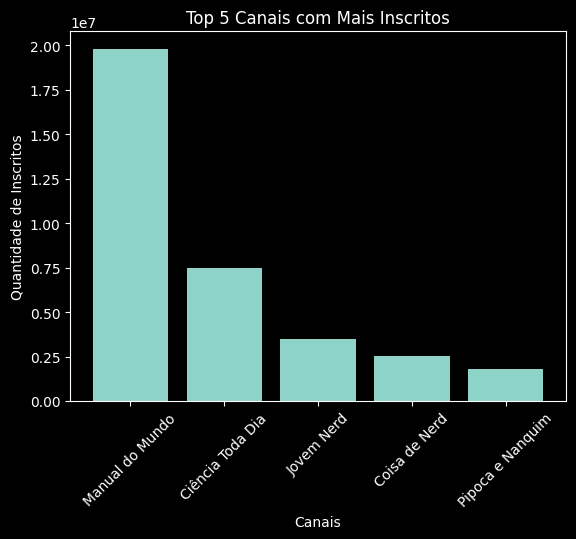

In [56]:
# Gráfico de barras
plt.bar(x, y)

# Título e rótulos
plt.title("Top 5 Canais com Mais Inscritos")
plt.xlabel("Canais")
plt.ylabel("Quantidade de Inscritos")

# Girar nomes no eixo X para não ficar sobreposto
plt.xticks(rotation=45)

# Mostrar gráfico
plt.show()

In [57]:
import numpy as np

In [58]:
x = canal_top["canal"]
y = canal_top["inscritos_num"]

In [59]:
plt.style.use("dark_background")  # Tema escuro moderno


In [60]:
cores = plt.cm.plasma(np.linspace(0.2, 0.9, len(x)))

In [61]:
plt.figure(figsize=(14, 9))

<Figure size 1400x900 with 0 Axes>

<Figure size 1400x900 with 0 Axes>

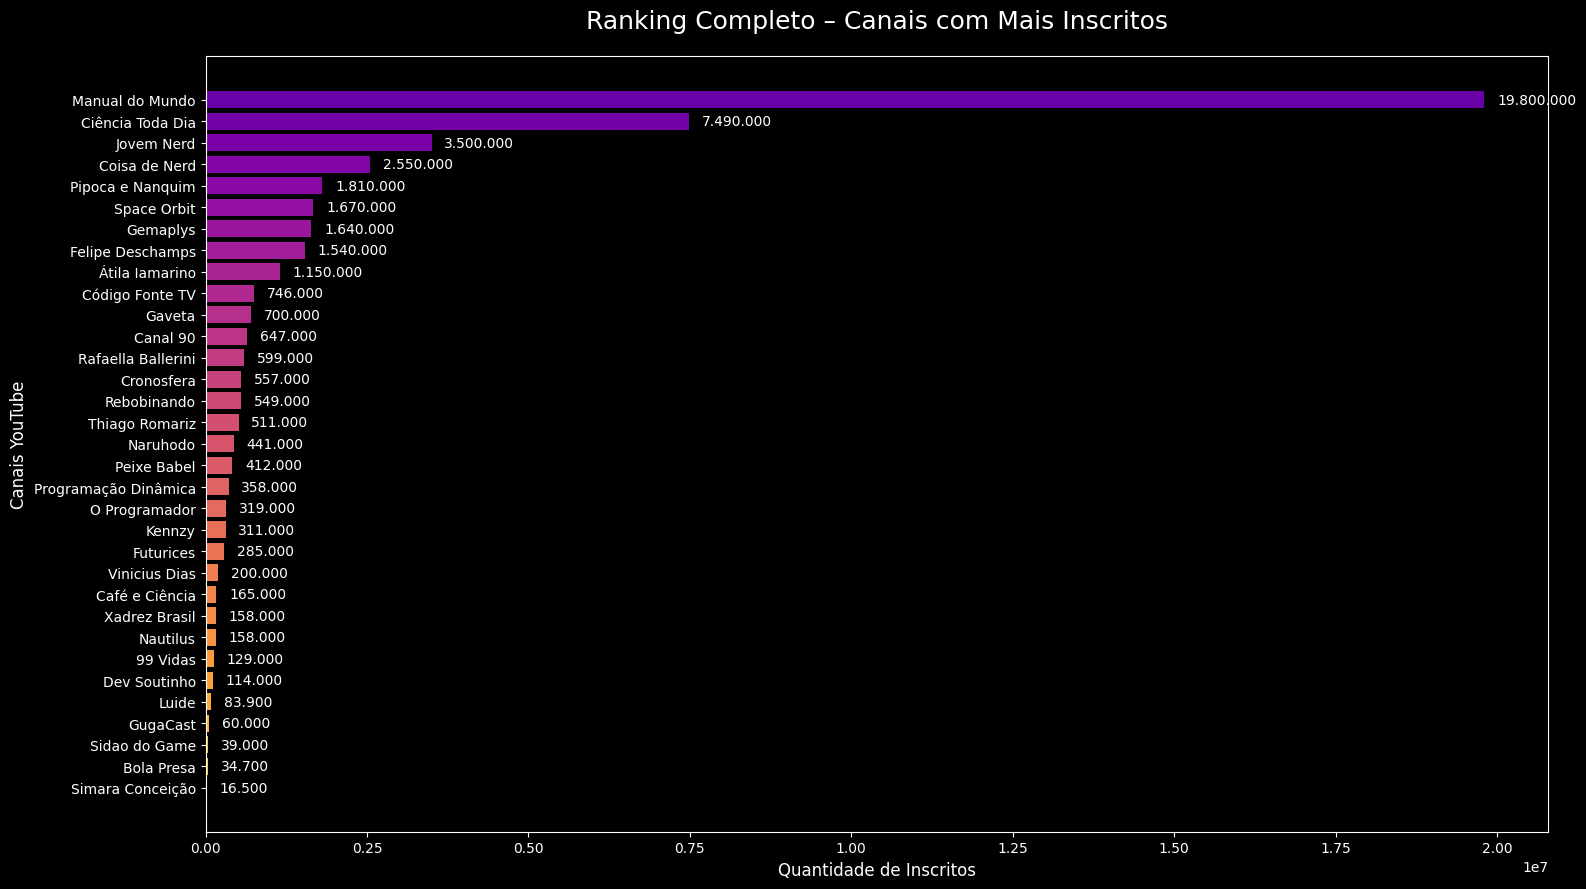

In [85]:
plt.figure(figsize=(16, 9))

bars = plt.barh(x, y, color=cores)

# Mostrar maior no topo
plt.gca().invert_yaxis()

# ============================
#   ADICIONAR VALORES
# ============================
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(y)*0.01,
             bar.get_y() + bar.get_height()/2,
             f"{width:,.0f}".replace(",", "."),
             va="center",
             fontsize=10,
             color="white")

# ============================
#   TÍTULOS E RÓTULOS
# ============================
plt.title("Ranking Completo – Canais com Mais Inscritos", fontsize=18, pad=20)
plt.xlabel("Quantidade de Inscritos", fontsize=12)
plt.ylabel("Canais YouTube", fontsize=12)

# Ajuste de margens
plt.tight_layout()

# ============================
#   SALVAR A IMAGEM EM PNG
# ============================
plt.savefig("grafico_canais_completo.png", dpi=600, bbox_inches="tight")

# Exibir
plt.show()

In [77]:
df.columns


Index(['canal', 'descrição', 'categoria', 'qtde_inscritos (aprox.)',
       'conhece_canal', 'inscritos_num'],
      dtype='object')

In [78]:
df_novo = df.drop(columns=['endereço'], errors='ignore')


In [79]:
df_novo = df.drop(columns=['qtde_inscritos (aprox.)'])



In [80]:
df_novo = df.drop(columns=['endereco'], errors='ignore')



In [81]:
import matplotlib.pyplot as plt

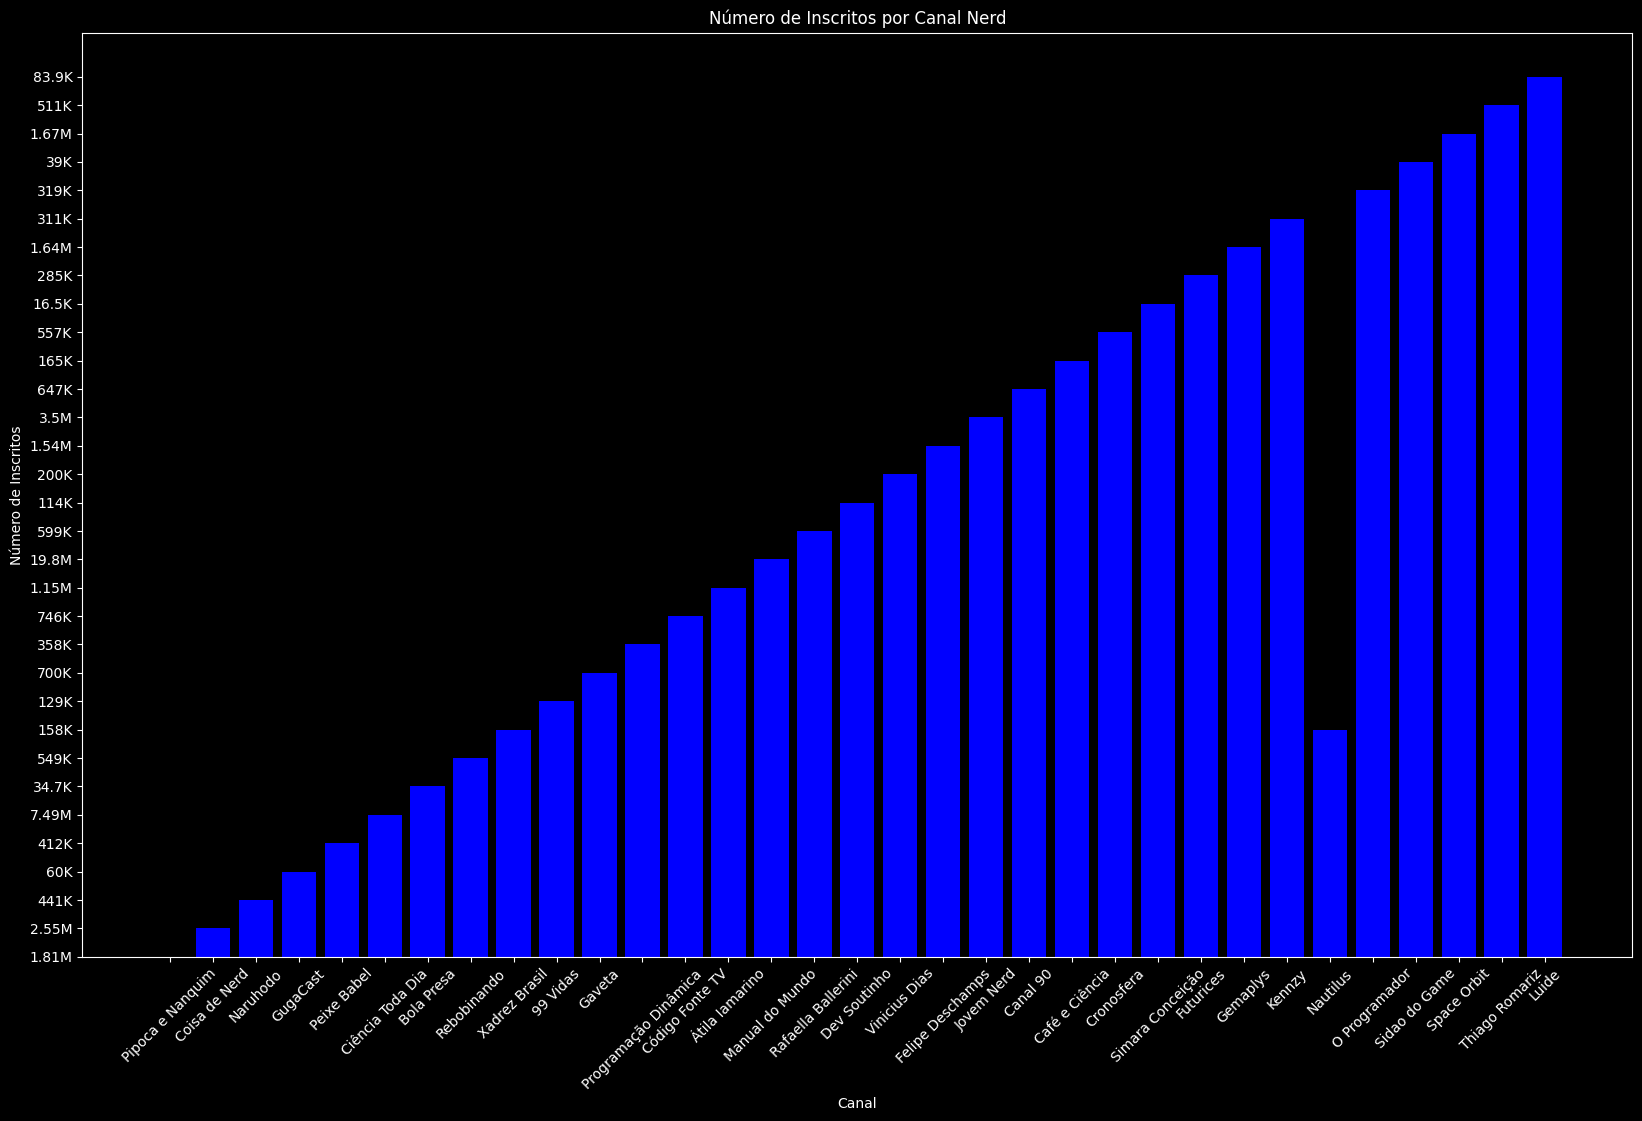

In [83]:
plt.figure(figsize=(20,12))
plt.bar(df_novo['canal'], df_novo['qtde_inscritos (aprox.)'], color='blue')
plt.xlabel('Canal')
plt.ylabel('Número de Inscritos')
plt.title('Número de Inscritos por Canal Nerd')
plt.xticks(rotation=45)
plt.show()
